
# 1. IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")



# 2. LOAD DATASET

In [3]:
file_path = "ecommerce_sales_raw_2000_rows.csv"

df = pd.read_csv(file_path)

print("DATASET LOADED")

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())


DATASET LOADED
Shape: (2008, 21)

First 5 rows:
    Order_ID  Order_Date  Customer_Age  Gender       State        Category  \
0  ORD100001  2025-02-02            59  Female     Gujarat  Home & Kitchen   
1  ORD100002  2025-10-10            20    Male       Delhi         Fashion   
2  ORD100003  2025-08-27            36  Female  Tamil Nadu          Beauty   
3  ORD100004  2025-06-10            39  Female   Karnataka          Beauty   
4  ORD100005  2025-06-08            55    Male   Rajasthan         Fashion   

   Product_Price  Quantity  Discount Payment_Method  ...  Customer_Rating  \
0         611.57         2       0.0    Credit Card  ...              3.8   
1        1642.20         1      10.0     Debit Card  ...              4.0   
2         808.50         3      20.0    Net Banking  ...              3.3   
3         410.83         4      30.0         Wallet  ...              5.0   
4         995.48         2      25.0            upi  ...              4.1   

   Membership Return


# 3. UNDERSTAND DATASET

In [4]:


print("DATASET INFORMATION")


print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

DATASET INFORMATION

Columns:
['Order_ID', 'Order_Date', 'Customer_Age', 'Gender', 'State', 'Category', 'Product_Price', 'Quantity', 'Discount', 'Payment_Method', 'Delivery_Days', 'Customer_Rating', 'Membership', 'Return_Status', 'Previous_Purchases', 'Shipping_Cost', 'Festival_Season', 'Coupon_Used', 'Device', 'Visit_Duration', 'Total_Sales']

Data Types:
Order_ID               object
Order_Date             object
Customer_Age            int64
Gender                 object
State                  object
Category               object
Product_Price         float64
Quantity                int64
Discount              float64
Payment_Method         object
Delivery_Days           int64
Customer_Rating       float64
Membership             object
Return_Status          object
Previous_Purchases      int64
Shipping_Cost         float64
Festival_Season        object
Coupon_Used            object
Device                 object
Visit_Duration        float64
Total_Sales           float64
dtype: obje

# 4. DATA CLEANING

In [5]:

print("DATA CLEANING")


# Make a copy
clean_df = df.copy()

# Convert Order_Date
clean_df["Order_Date"] = pd.to_datetime(
    clean_df["Order_Date"],
    errors="coerce"
)

# Remove duplicate rows
print("Duplicates before:", clean_df.duplicated().sum())

clean_df = clean_df.drop_duplicates()

print("Duplicates after:", clean_df.duplicated().sum())

# Fix inconsistent Gender values
clean_df["Gender"] = clean_df["Gender"].replace({
    "male": "Male",
    "F": "Female"
})

# Fix inconsistent Payment Method
clean_df["Payment_Method"] = clean_df["Payment_Method"].replace({
    "upi": "UPI"
})

# Numerical columns
numeric_columns = [
    "Customer_Age",
    "Product_Price",
    "Quantity",
    "Discount",
    "Delivery_Days",
    "Customer_Rating",
    "Previous_Purchases",
    "Shipping_Cost",
    "Visit_Duration"
]

# Fill missing numerical values with median
for column in numeric_columns:
    clean_df[column] = clean_df[column].fillna(
        clean_df[column].median()
    )

# Check missing values
print("\nMissing values after cleaning:")
print(clean_df.isnull().sum())


DATA CLEANING
Duplicates before: 8
Duplicates after: 0

Missing values after cleaning:
Order_ID              0
Order_Date            0
Customer_Age          0
Gender                0
State                 0
Category              0
Product_Price         0
Quantity              0
Discount              0
Payment_Method        0
Delivery_Days         0
Customer_Rating       0
Membership            0
Return_Status         0
Previous_Purchases    0
Shipping_Cost         0
Festival_Season       0
Coupon_Used           0
Device                0
Visit_Duration        0
Total_Sales           0
dtype: int64


# 5. EXPLORATORY DATA ANALYSIS

# Sales by Category


Sales by Category:
Category
Beauty            999702.19
Electronics       970894.90
Fashion           960684.90
Sports            929916.63
Home & Kitchen    882129.18
Books             856571.37
Name: Total_Sales, dtype: float64


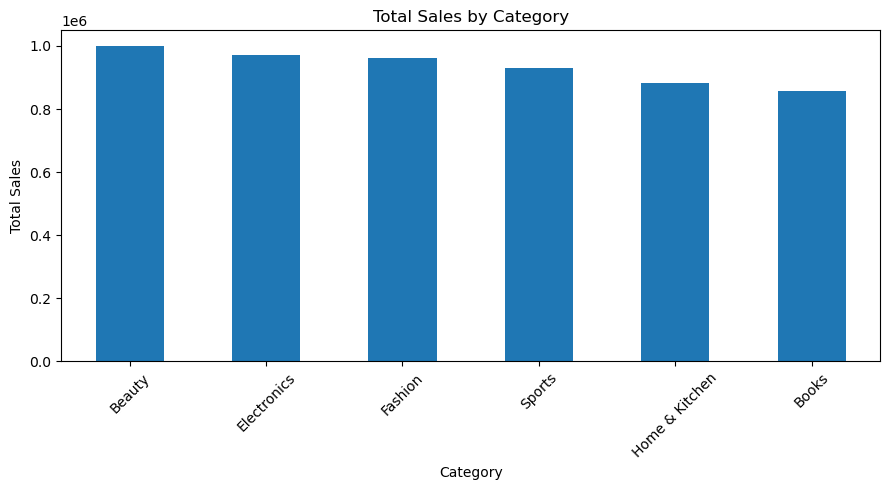

In [6]:
category_sales = clean_df.groupby(
    "Category"
)["Total_Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by Category:")
print(category_sales)

plt.figure(figsize=(9, 5))

category_sales.plot(kind="bar")

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sales by State


Sales by State:
State
Tamil Nadu        657056.76
Maharashtra       638223.38
Gujarat           612225.53
Kerala            572280.22
Telangana         550719.29
Rajasthan         540140.46
Delhi             536205.13
Karnataka         521629.36
West Bengal       521534.50
Andhra Pradesh    449884.54
Name: Total_Sales, dtype: float64


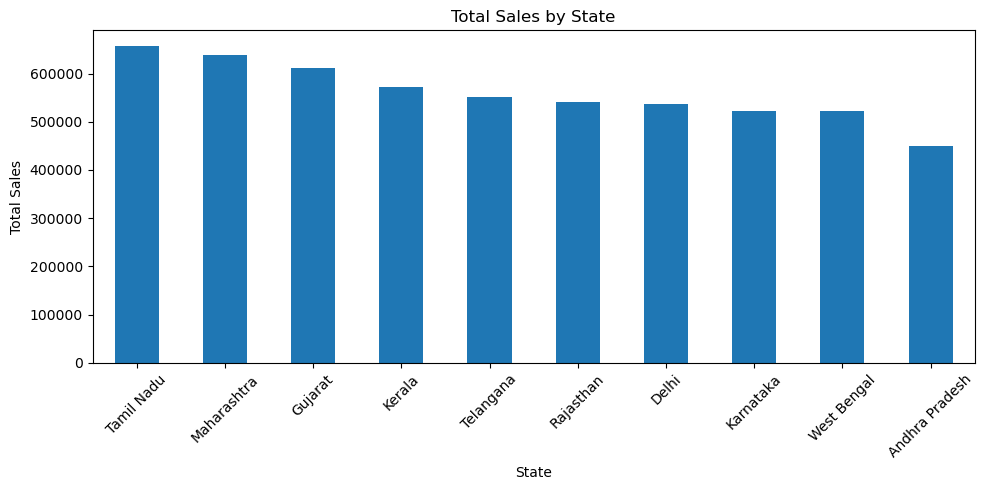

In [7]:

state_sales = clean_df.groupby(
    "State"
)["Total_Sales"].sum().sort_values(
    ascending=False
)

print("\nSales by State:")
print(state_sales)

plt.figure(figsize=(10, 5))

state_sales.plot(kind="bar")

plt.title("Total Sales by State")
plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Sales by Membership

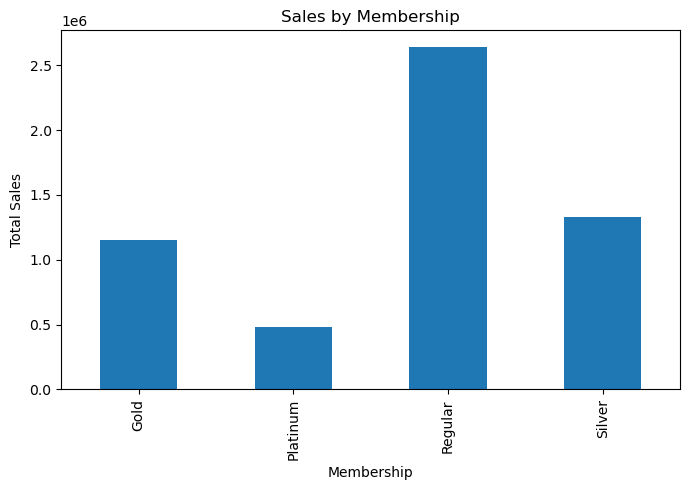

In [8]:

membership_sales = clean_df.groupby(
    "Membership"
)["Total_Sales"].sum()

plt.figure(figsize=(7, 5))

membership_sales.plot(kind="bar")

plt.title("Sales by Membership")
plt.xlabel("Membership")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()



# Sales Distribution


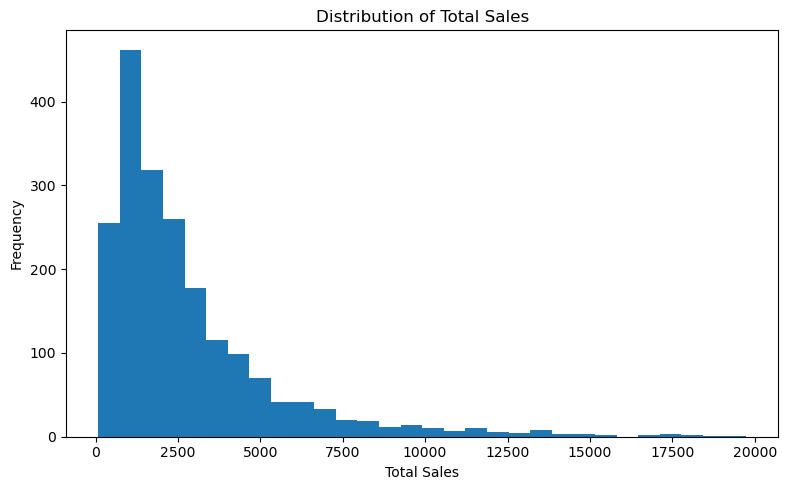

In [9]:

plt.figure(figsize=(8, 5))

plt.hist(
    clean_df["Total_Sales"],
    bins=30
)

plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# Discount vs Sales

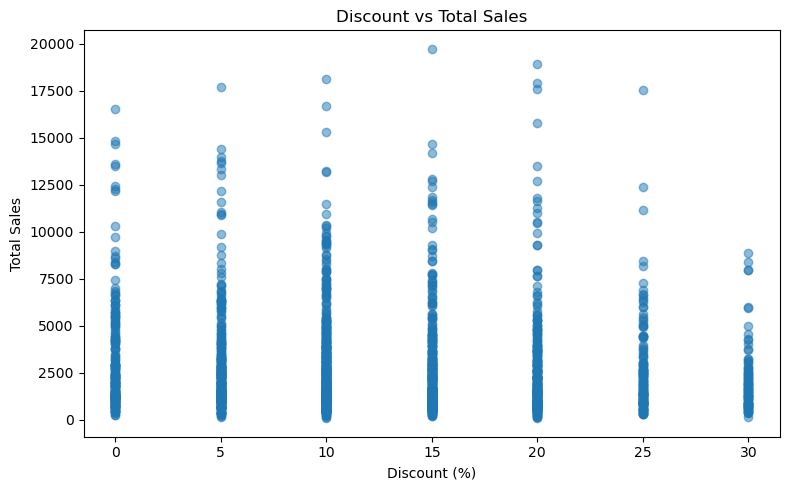

In [10]:

plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Discount"],
    clean_df["Total_Sales"],
    alpha=0.5
)

plt.title("Discount vs Total Sales")
plt.xlabel("Discount (%)")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()



# Product Price vs Sales

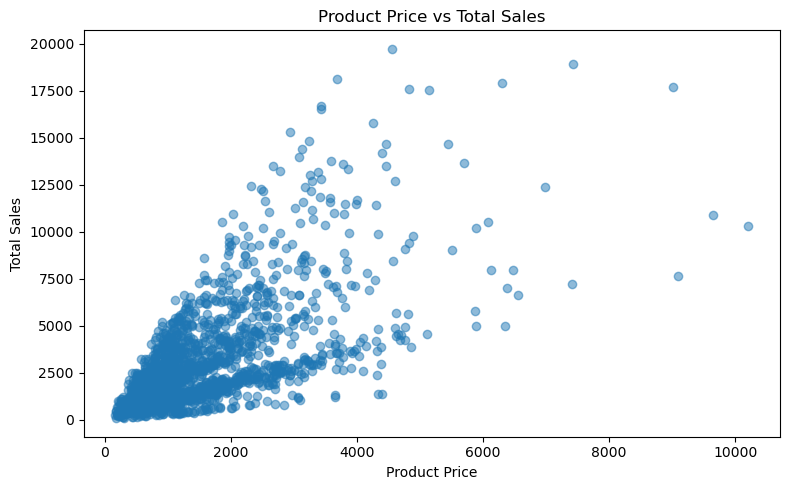

In [11]:

plt.figure(figsize=(8, 5))

plt.scatter(
    clean_df["Product_Price"],
    clean_df["Total_Sales"],
    alpha=0.5
)

plt.title("Product Price vs Total Sales")
plt.xlabel("Product Price")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()


# Correlation


Correlation with Total Sales:
Total_Sales           1.000000
Product_Price         0.665695
Quantity              0.523868
Previous_Purchases    0.041888
Customer_Rating       0.011718
Shipping_Cost         0.008471
Visit_Duration        0.004413
Customer_Age         -0.000774
Delivery_Days        -0.016624
Discount             -0.080163
Name: Total_Sales, dtype: float64


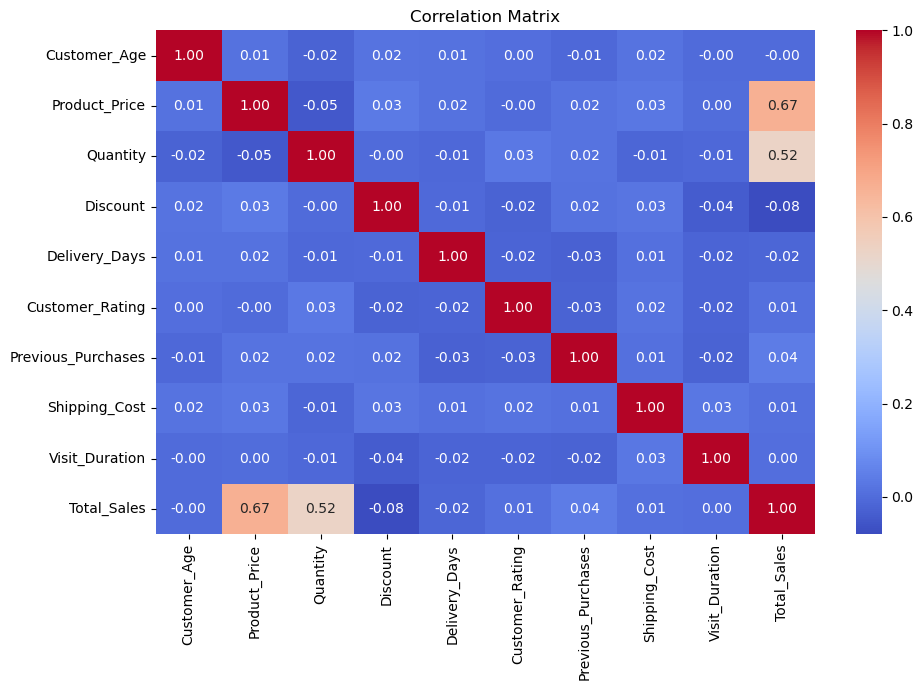

In [12]:

numeric_df = clean_df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

print("\nCorrelation with Total Sales:")
print(
    correlation["Total_Sales"]
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

# 6. FEATURE ENGINEERING

In [13]:

print("FEATURE ENGINEERING")


# Date features
clean_df["Year"] = clean_df["Order_Date"].dt.year
clean_df["Month"] = clean_df["Order_Date"].dt.month
clean_df["Day"] = clean_df["Order_Date"].dt.day

# Weekend
clean_df["Is_Weekend"] = (
    clean_df["Order_Date"]
    .dt.dayofweek >= 5
).astype(int)

# Gross amount
clean_df["Gross_Amount"] = (
    clean_df["Product_Price"] *
    clean_df["Quantity"]
)

# Discount amount
clean_df["Discount_Amount"] = (
    clean_df["Gross_Amount"] *
    clean_df["Discount"] / 100
)

print("\nNew Features Created:")
print(
    [
        "Year",
        "Month",
        "Day",
        "Is_Weekend",
        "Gross_Amount",
        "Discount_Amount"
    ]
)


FEATURE ENGINEERING

New Features Created:
['Year', 'Month', 'Day', 'Is_Weekend', 'Gross_Amount', 'Discount_Amount']


# 7. DEFINE FEATURES AND TARGET

In [14]:

print("FEATURE AND TARGET SELECTION")

# Target
y = clean_df["Total_Sales"]

# Remove ID, date and target
X = clean_df.drop(
    columns=[
        "Total_Sales",
        "Order_ID",
        "Order_Date"
    ]
)

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("Total_Sales")

FEATURE AND TARGET SELECTION
Features:
['Customer_Age', 'Gender', 'State', 'Category', 'Product_Price', 'Quantity', 'Discount', 'Payment_Method', 'Delivery_Days', 'Customer_Rating', 'Membership', 'Return_Status', 'Previous_Purchases', 'Shipping_Cost', 'Festival_Season', 'Coupon_Used', 'Device', 'Visit_Duration', 'Year', 'Month', 'Day', 'Is_Weekend', 'Gross_Amount', 'Discount_Amount']

Target:
Total_Sales


# 8. TRAIN TEST SPLIT

In [15]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)



Training Data: (1600, 24)
Testing Data: (400, 24)


# 9. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES

In [16]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("\nCategorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)


Categorical Features:
['Gender', 'State', 'Category', 'Payment_Method', 'Membership', 'Return_Status', 'Festival_Season', 'Coupon_Used', 'Device']

Numerical Features:
['Customer_Age', 'Product_Price', 'Quantity', 'Discount', 'Delivery_Days', 'Customer_Rating', 'Previous_Purchases', 'Shipping_Cost', 'Visit_Duration', 'Year', 'Month', 'Day', 'Is_Weekend', 'Gross_Amount', 'Discount_Amount']


# 10. PREPROCESSING

In [17]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            "passthrough",
            numerical_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)


# 11. LINEAR REGRESSION

In [18]:

print("LINEAR REGRESSION")

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(
    X_test
)


LINEAR REGRESSION


# 12. DECISION TREE

In [19]:

print("DECISION TREE")


tree_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            DecisionTreeRegressor(
                max_depth=10,
                random_state=42
            )
        )
    ]
)

tree_model.fit(
    X_train,
    y_train
)

tree_predictions = tree_model.predict(
    X_test
)


DECISION TREE


# 13. RANDOM FOREST

In [20]:

print("RANDOM FOREST")


rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=15,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)



RANDOM FOREST


# 14. MODEL EVALUATION FUNCTION

In [21]:

def evaluate_model(
    model_name,
    actual,
    predicted
):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    r2 = r2_score(
        actual,
        predicted
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

# 15. MODEL COMPARISON

In [22]:

results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_test,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_predictions
    )
)

results_df = pd.DataFrame(results)


print("MODEL COMPARISON")


print(
    results_df.to_string(
        index=False
    )
)



MODEL COMPARISON
            Model        MAE       RMSE       R2
Linear Regression 334.637838 663.061779 0.946716
    Decision Tree 295.992319 560.496336 0.961926
    Random Forest 265.732671 651.751164 0.948519


# 16. RANDOM FOREST HYPERPARAMETER TUNING

In [23]:

print("RANDOM FOREST HYPERPARAMETER TUNING")


param_grid = {

    "model__n_estimators": [
        100,
        200
    ],

    "model__max_depth": [
        10,
        15,
        20
    ],

    "model__min_samples_split": [
        2,
        5
    ],

    "model__min_samples_leaf": [
        1,
        2
    ]
}


grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(
    X_train,
    y_train
)



RANDOM FOREST HYPERPARAMETER TUNING
Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         'passthrough',
                                                                         ['Customer_Age',
                                                                          'Product_Price',
                                                                          'Quantity',
                                                                          'Discount',
                                                                          'Delivery_Days',
                                                                          'Customer_Rating',
                                                                          'Previous_Purchases',
                                                                          'Shipping_Cost',
                                                                          'Visit_Duration',
                                                                          'Year',
                                                                          'Month',
                                                                          'Day',
                                                                          'Is_Weekend',
                                                                          'Gross_Amount',
                                                                          'Discount_Amount']),
                                                                        ('categorical',
                                                                         OneHo...
                                                                          'Payment_Method',
                                                                          'Membership',
                                                                          'Return_Status',
                                                                          'Festival_Season',
                                                                          'Coupon_Used',
                                                                          'Device'])])),
                                       ('model',
                                        RandomForestRegressor(max_depth=15,
                                                              n_estimators=200,
                                                              n_jobs=-1,
                                                              random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, 15, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='r2', verbose=1)

# 17. BEST MODEL

In [24]:
best_model = grid_search.best_estimator_

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation R2:")
print(grid_search.best_score_)



Best Parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best Cross Validation R2:
0.9573725134515143


# 18. FINAL MODEL EVALUATION

In [25]:

best_predictions = best_model.predict(
    X_test
)

final_mae = mean_absolute_error(
    y_test,
    best_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        best_predictions
    )
)

final_r2 = r2_score(
    y_test,
    best_predictions
)

print("FINAL MODEL PERFORMANCE")

print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R2  :", final_r2)

FINAL MODEL PERFORMANCE
MAE : 263.2479842453653
RMSE: 631.2068451470593
R2  : 0.9517129662561714


# 19. ACTUAL VS PREDICTED


Actual vs Predicted:
   Actual_Sales  Predicted_Sales  Prediction_Error
0       2917.77      2978.400144        -60.630144
1       3099.76      3270.502100       -170.742100
2       2675.81      2685.755525         -9.945525
3       1197.09      1191.344918          5.745082
4       3316.98      3332.047396        -15.067396
5       7971.14     11802.447080      -3831.307080
6       1680.50      1533.825611        146.674389
7        895.21       971.723296        -76.513296
8       4790.86      4364.421750        426.438250
9       1676.38      1756.179969        -79.799969


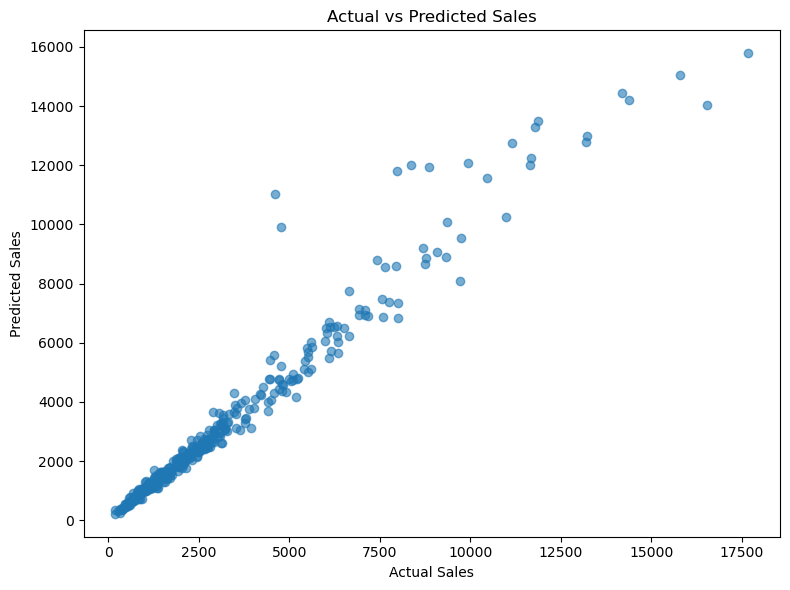

In [26]:

comparison_df = pd.DataFrame({

    "Actual_Sales": y_test.values,

    "Predicted_Sales": best_predictions

})

comparison_df["Prediction_Error"] = (
    comparison_df["Actual_Sales"]
    -
    comparison_df["Predicted_Sales"]
)

print("\nActual vs Predicted:")
print(comparison_df.head(10))


plt.figure(figsize=(8, 6))

plt.scatter(
    comparison_df["Actual_Sales"],
    comparison_df["Predicted_Sales"],
    alpha=0.6
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title(
    "Actual vs Predicted Sales"
)

plt.tight_layout()
plt.show()


# 20. SAVE PREDICTIONS FOR POWER BI

In [28]:

powerbi_predictions = X_test.copy()

powerbi_predictions["Actual_Sales"] = (
    y_test.values
)

powerbi_predictions["Predicted_Sales"] = (
    best_predictions
)

powerbi_predictions["Prediction_Error"] = (
    powerbi_predictions["Actual_Sales"]
    -
    powerbi_predictions["Predicted_Sales"]
)

powerbi_predictions.to_csv(
    "ecommerce_sales_predictions.csv",
    index=False
)

print(
    "\nPower BI prediction file saved:"
    " ecommerce_sales_predictions.csv"
)



Power BI prediction file saved: ecommerce_sales_predictions.csv


# 21. SAVE CLEANED DATASET

In [29]:

clean_df.to_csv(
    "ecommerce_sales_cleaned.csv",
    index=False
)

print(
    "Cleaned dataset saved:"
    " ecommerce_sales_cleaned.csv"
)



Cleaned dataset saved: ecommerce_sales_cleaned.csv


# 22. SAVE FINAL ML MODEL

In [30]:

joblib.dump(
    best_model,
    "ecommerce_sales_model.pkl"
)

print(
    "ML model saved:"
    " ecommerce_sales_model.pkl"
)



ML model saved: ecommerce_sales_model.pkl


# 23. SAVE MODEL PERFORMANCE FOR POWER BI

In [31]:
model_performance = pd.DataFrame({

    "Metric": [
        "MAE",
        "RMSE",
        "R2"
    ],

    "Value": [
        final_mae,
        final_rmse,
        final_r2
    ]
})

model_performance.to_csv(
    "model_performance.csv",
    index=False
)


# 24. FINAL SUMMARY

In [32]:

print("PROJECT COMPLETED")

print("\nFinal Model: Optimized Random Forest Regressor")

print("\nFinal Performance:")
print("MAE :", round(final_mae, 2))
print("RMSE:", round(final_rmse, 2))
print("R2  :", round(final_r2, 4))

print("\nFiles Generated:")
print("1. ecommerce_sales_cleaned.csv")
print("2. ecommerce_sales_predictions.csv")
print("3. model_performance.csv")
print("4. ecommerce_sales_model.pkl")

print("\nNext Step:")
print("Import the CSV files into Power BI and build the dashboard.")

PROJECT COMPLETED

Final Model: Optimized Random Forest Regressor

Final Performance:
MAE : 263.25
RMSE: 631.21
R2  : 0.9517

Files Generated:
1. ecommerce_sales_cleaned.csv
2. ecommerce_sales_predictions.csv
3. model_performance.csv
4. ecommerce_sales_model.pkl

Next Step:
Import the CSV files into Power BI and build the dashboard.
